In [1]:
!pip install tensorflow
!pip install -q openai-whisper


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa           # load audio + feature extraction
import librosa.display   # visualize spectrogram
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import load_model
import whisper

In [3]:
# Define dataset path
DATASET_PATH = "voice_dataset"
print("Dataset path set:", DATASET_PATH)

Dataset path set: voice_dataset


In [4]:
# Print dataset structure
for root, dirs, files in os.walk(DATASET_PATH):
    print(f"Folder: {root}")
    print(f"Number of files: {len(files)}")
    print("-" * 40)

Folder: voice_dataset
Number of files: 0
----------------------------------------
Folder: voice_dataset\ai
Number of files: 0
----------------------------------------
Folder: voice_dataset\ai\bengali
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\english
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\hindi
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\kannada
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\malayalam
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\marathi
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\tamil
Number of files: 300
----------------------------------------
Folder: voice_dataset\ai\telugu
Number of files: 300
----------------------------------------
Folder: voice_dataset\human
Number of files: 0
-----------------------------

In [5]:
# Load and inspect one sample audio file
sample_file = "voice_dataset/human/english/hu_eng_001.wav"

# Load audio
audio, sr = librosa.load(sample_file, sr=None)

print("Original Sample Rate:", sr)

# Resample
target_sr = 16000
audio_resampled = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

print("New Sample Rate:", target_sr)
print("New Duration:", len(audio_resampled)/target_sr)


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original Sample Rate: 48000
New Sample Rate: 16000
New Duration: 4.104


In [6]:
# Convert audio → Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio_resampled,
    sr=target_sr,
    n_mels=128,   # number of Mel bands (image height)
    fmax=8000     # max frequency
)

# Convert to log scale
log_mel_spec = librosa.power_to_db(mel_spec)

print("Spectrogram shape:", log_mel_spec.shape)

Spectrogram shape: (128, 129)


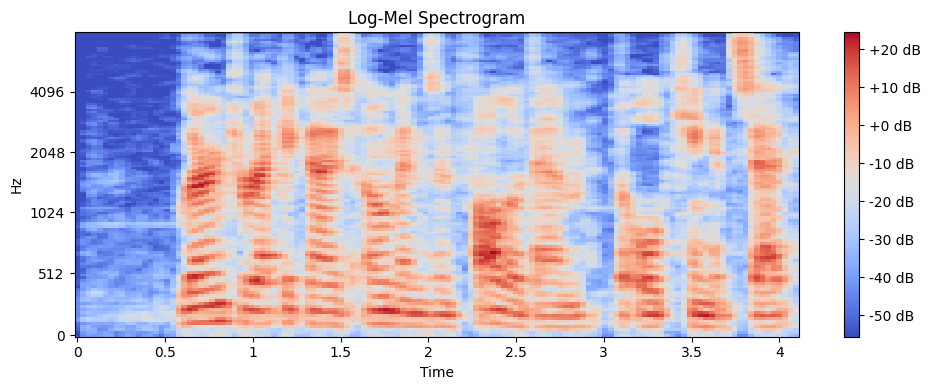

In [7]:
# Display the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    log_mel_spec,
    sr=target_sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

In [8]:
OUTPUT_PATH = "spectrograms"
print("Output path set")

Output path set


In [ ]:
if os.path.exists(os.path.join(OUTPUT_PATH, "human")):
    print("Dataset already processed — Skipping")

else:
    print("Processing required")

    # Process FULL dataset
    for category in ["human", "ai"]:

        category_path = os.path.join(DATASET_PATH, category)

        for language in os.listdir(category_path):

            input_folder = os.path.join(category_path, language)
            output_folder = os.path.join(OUTPUT_PATH, category, language)

            os.makedirs(output_folder, exist_ok=True)

            count = 0

            for file_name in os.listdir(input_folder):
                if file_name.lower().endswith(('.wav', '.mp3')):

                    file_path = os.path.join(input_folder, file_name)

                    # Load audio
                    audio, sr = librosa.load(file_path, sr=None)

                    # Resample
                    audio_resampled = librosa.resample(audio, orig_sr=sr, target_sr=16000)

                    # Generate spectrogram
                    mel_spec = librosa.feature.melspectrogram(
                        y=audio_resampled,
                        sr=16000,
                        n_mels=128,
                        fmax=8000
                    )

                    log_mel_spec = librosa.power_to_db(mel_spec)

                    # Save image
                    base_name = os.path.splitext(file_name)[0]
                    save_path = os.path.join(output_folder, base_name + ".png")

                    plt.figure(figsize=(3,3))
                    librosa.display.specshow(log_mel_spec, sr=16000)
                    plt.axis('off')
                    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
                    plt.close()

                    count += 1

            print(f"{category}/{language}: {count} files processed")

Processing required
human/bengali: 300 files processed
human/english: 300 files processed
human/hindi: 300 files processed
human/kannada: 300 files processed
human/malayalam: 300 files processed
human/marathi: 300 files processed
human/tamil: 300 files processed
human/telugu: 300 files processed
ai/bengali: 300 files processed


In [ ]:
# Path to spectrogram dataset
SPECTROGRAM_PATH = "spectrograms"
print("Spectrogram path set ")

Spectrogram path set 


In [ ]:
# Define label mappings
voice_map = {
    "human": 0,
    "ai": 1
}

language_map = {
    "english": 0,
    "hindi": 1,
    "tamil": 2,
    "telugu": 3,
    "malayalam": 4,
    "marathi": 5,
    "bengali": 6,
    "kannada": 7
}

print("Label mappings created ")

Label mappings created 


In [ ]:
# Load spectrogram images and create dataset
IMG_SIZE = 128
X = []
y_type = []
y_lang = []

for category in ["human", "ai"]:
    category_path = os.path.join(SPECTROGRAM_PATH, category)

    for language in os.listdir(category_path):
        folder_path = os.path.join(category_path, language)

        for file_name in os.listdir(folder_path):
            if file_name.endswith(".png"):

                img_path = os.path.join(folder_path, file_name)

                # Read image
                img = cv2.imread(img_path)

                # Resize
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalize
                img = img / 255.0

                X.append(img)
                y_type.append(voice_map[category])
                y_lang.append(language_map[language])

print("Dataset loaded ")
print("Total samples:", len(X))

Dataset loaded 
Total samples: 4800


In [ ]:
# Convert to arrays
X = np.array(X)
y_type = np.array(y_type)
y_lang = np.array(y_lang)

# Split
X_train, X_val, y_type_train, y_type_val, y_lang_train, y_lang_val = train_test_split(
    X, y_type, y_lang,
    test_size=0.2,
    random_state=42,
    stratify=y_lang
)

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))

Train samples: 3840
Validation samples: 960


In [ ]:
# Input layer
input_layer = Input(shape=(128, 128, 3))

# CNN layers
x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

# Flatten
x = Flatten()(x)

# Shared dense layer
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# Output 1: Human vs AI
type_output = Dense(1, activation='sigmoid', name='type_output')(x)

# Output 2: Language classification
lang_output = Dense(8, activation='softmax', name='lang_output')(x)

# Model
model = Model(inputs=input_layer, outputs=[type_output, lang_output])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  3,211,392 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_output (Dense) │ (None, 1)         │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lang_output (Dense) │ (None, 8)         │      1,032 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,305,801 (12.61 MB)

 Trainable params: 3,305,801 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',

    loss={
        'type_output': 'binary_crossentropy',
        'lang_output': 'sparse_categorical_crossentropy'
    },

    metrics={
        'type_output': 'accuracy',
        'lang_output': 'accuracy'
    }
)

In [ ]:
history = model.fit(
    X_train,
    {
        'type_output': y_type_train,
        'lang_output': y_lang_train
    },

    validation_data=(
        X_val,
        {
            'type_output': y_type_val,
            'lang_output': y_lang_val
        }
    ),

    epochs=10,
    batch_size=32
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - lang_output_accuracy: 0.2229 - lang_output_loss: 1.9900 - loss: 2.4503 - type_output_accuracy: 0.7870 - type_output_loss: 0.4603 - val_lang_output_accuracy: 0.3688 - val_lang_output_loss: 1.7700 - val_loss: 2.0641 - val_type_output_accuracy: 0.8833 - val_type_output_loss: 0.2941
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - lang_output_accuracy: 0.3677 - lang_output_loss: 1.6987 - loss: 1.9744 - type_output_accuracy: 0.8883 - type_output_loss: 0.2757 - val_lang_output_accuracy: 0.4365 - val_lang_output_loss: 1.5690 - val_loss: 1.7833 - val_type_output_accuracy: 0.9135 - val_type_output_loss: 0.2143
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - lang_output_accuracy: 0.4581 - lang_output_loss: 1.4836 - loss: 1.6670 - type_output_accuracy: 0.9367 - type_output_loss: 0.1834 - val_lang_output_accuracy: 0.5219 - val_lang_output_loss: 1.3547 - val_loss: 1.4936 - val_type_output_accuracy: 0.9521 - val_type_output_loss: 0

In [ ]:
model.save("/content/drive/MyDrive/model_v2.keras")

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/model_v2.keras"

model = load_model(MODEL_PATH)

print("Model loaded successfully ")

Model loaded successfully 


In [ ]:
whisper_model = whisper.load_model("base")
print("Whisper loaded ")

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 254MiB/s]


Whisper loaded 


In [ ]:
file_name = '/content/The weather is very .mp3'
result = whisper_model.transcribe(file_name)

whisper_text = result["text"]
whisper_lang = result["language"]

print("Whisper Language:", whisper_lang)
print("Transcription:", whisper_text)

Whisper Language: en
Transcription:  The weather is very pleasant today, making it a perfect time to go outside or spend quality time with your loved ones.


In [ ]:
uploaded = files.upload()

Saving The weather is very .mp3 to The weather is very  (1).mp3


In [ ]:
# Get uploaded file name
file_name = list(uploaded.keys())[0]

audio, sr = librosa.load(file_name, sr=None)

audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

# Generate spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=16000,
    n_mels=128,
    fmax=8000
)

log_mel_spec = librosa.power_to_db(mel_spec)

# Convert spectrogram to image
plt.figure(figsize=(3,3))
librosa.display.specshow(log_mel_spec, sr=16000)
plt.axis('off')

temp_path = "temp.png"
plt.savefig(temp_path, bbox_inches='tight', pad_inches=0)
plt.close()

# Read image
img = cv2.imread(temp_path)
img = cv2.resize(img, (128, 128))
img = img / 255.0

# Expand dimensions for model
img = np.expand_dims(img, axis=0)

# Predict
type_pred, _ = model.predict(img)

# TYPE (Human vs AI)
type_score = float(type_pred[0][0])
type_label = "AI" if type_score > 0.5 else "Human"
type_confidence = type_score if type_label == "AI" else (1 - type_score)

# LANGUAGE
result = whisper_model.transcribe(file_name, fp16=False)

whisper_text = result["text"]
whisper_lang = result["language"]

whisper_lang_map = {
    "en": "english",
    "hi": "hindi",
    "ta": "tamil",
    "te": "telugu",
    "ml": "malayalam",
    "kn": "kannada",
    "mr": "marathi",
    "bn": "bengali"
}

lang_label = whisper_lang_map.get(whisper_lang, "unknown")
lang_confidence = min(0.95, max(0.6, len(whisper_text) / 60))

print("Type:", type_label)
print("Language:", lang_label)
print("Type Confidence:", round(type_confidence, 3))
print("Language Confidence:", round(lang_confidence, 3))
print("Transcription:", whisper_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Type: AI
Language: english
Type Confidence: 0.949
Language Confidence: 0.95
Transcription:  The weather is very pleasant today, making it a perfect time to go outside or spend quality time with your loved ones.
